<a href="https://colab.research.google.com/github/adityaaaa342/Pattern-Recognition-/blob/main/Practical_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd

In [17]:
np.random.seed(42)

# 100 samples, 10 features
X = np.random.rand(100, 10)

# Random binary target
y = np.random.randint(0, 2, 100)

df = pd.DataFrame(X, columns=[f'Feature_{i+1}' for i in range(10)])
df['Target'] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,0.374540,0.950714,0.731994,0.598658,0.156019,0.155995,0.058084,0.866176,0.601115,0.708073,0
1,0.020584,0.969910,0.832443,0.212339,0.181825,0.183405,0.304242,0.524756,0.431945,0.291229,1
2,0.611853,0.139494,0.292145,0.366362,0.456070,0.785176,0.199674,0.514234,0.592415,0.046450,1
3,0.607545,0.170524,0.065052,0.948886,0.965632,0.808397,0.304614,0.097672,0.684233,0.440152,1
4,0.122038,0.495177,0.034389,0.909320,0.258780,0.662522,0.311711,0.520068,0.546710,0.184854,1


In [23]:
X = df.drop('Target', axis=1)
y = df['Target']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("PCA Shape:", X_train_pca.shape)
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

PCA Shape: (80, 5)
Explained Variance Ratio:
[0.17870238 0.14345008 0.1202303  0.10610806 0.08940791]


In [27]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print("LDA Shape:", X_train_lda.shape)

LDA Shape: (80, 1)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Original Accuracy:", accuracy_score(y_test, pred))

Original Accuracy: 0.45


In [29]:
model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(X_train_pca, y_train)

pred_pca = model_pca.predict(X_test_pca)

print("PCA Accuracy:", accuracy_score(y_test, pred_pca))

PCA Accuracy: 0.55


In [30]:
model_lda = LogisticRegression(max_iter=1000)

model_lda.fit(X_train_lda, y_train)

pred_lda = model_lda.predict(X_test_lda)

print("LDA Accuracy:", accuracy_score(y_test, pred_lda))

LDA Accuracy: 0.4


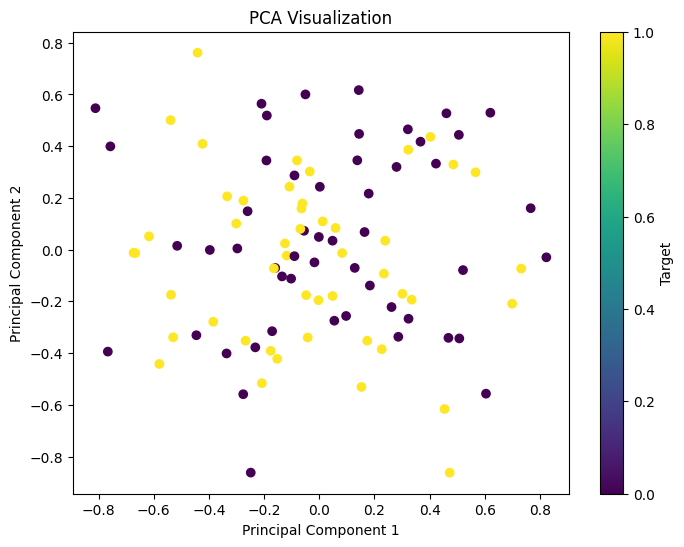

In [31]:
import matplotlib.pyplot as plt

# Apply PCA with 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target")
plt.show()

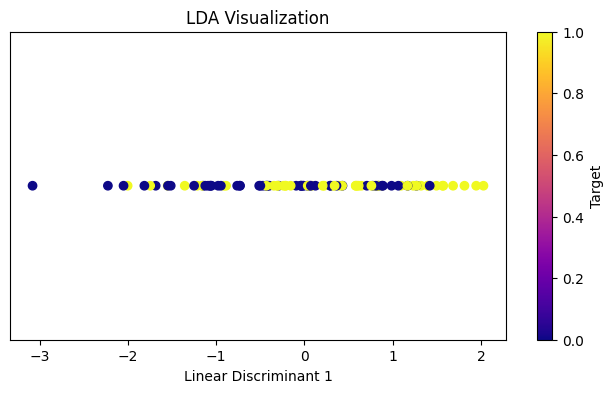

In [32]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

plt.figure(figsize=(8,4))
plt.scatter(X_lda, [0]*len(X_lda), c=y, cmap='plasma')
plt.title("LDA Visualization")
plt.xlabel("Linear Discriminant 1")
plt.yticks([])
plt.colorbar(label="Target")
plt.show()

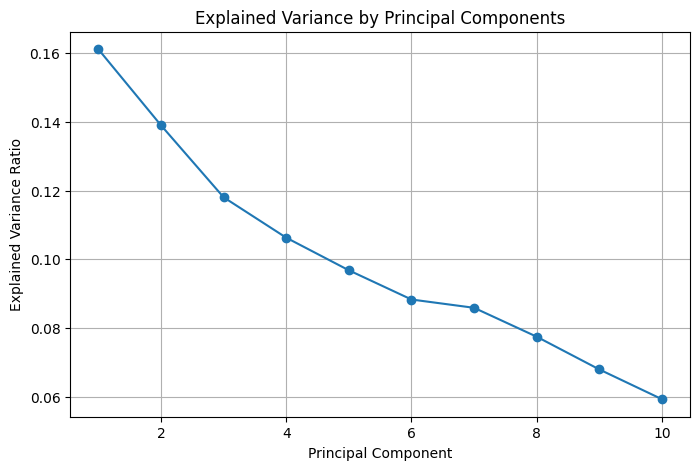

In [33]:
pca = PCA()
pca.fit(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_,
         marker='o')

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

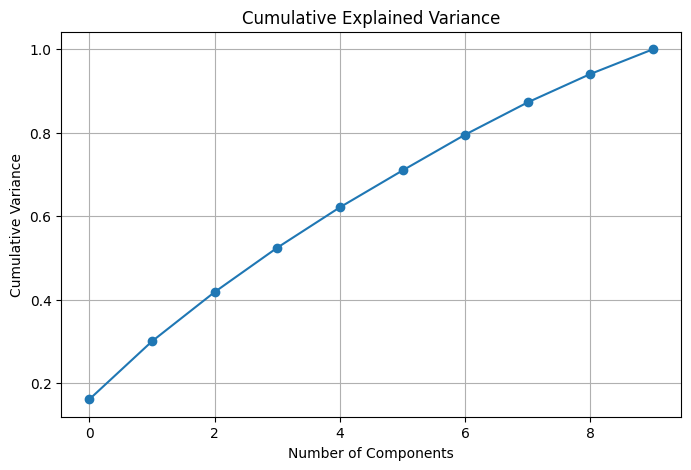

In [34]:
import numpy as np

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.show()